# GradCam

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "1"  # 只使用第0号GPU
import warnings
warnings.filterwarnings('ignore')
warnings.simplefilter('ignore')
from torchvision.models.segmentation import deeplabv3_resnet50
import torch
import torch.functional as F
import numpy as np
import requests
import torchvision
from PIL import Image
from pytorch_grad_cam.utils.image import show_cam_on_image, preprocess_image

import sys
sys.path.append('/nas_data/LSH/OpenSTL-MOR')
from openstl.datasets.dataloader_human import load_data

dataloader_train, _, dataloader_test = \
        load_data(batch_size=8,
                  val_batch_size=4,
                  data_root='/nas_data/LSH/data/',
                  num_workers=4,
                  pre_seq_length=4, aft_seq_length=4,
                  use_prefetcher=True, distributed=False)

print(len(dataloader_train), len(dataloader_test))
batch_x, batch_y = None, None
for item in dataloader_train:
    print(item[0].shape, item[1].shape)
    batch_x = item[0]
    batch_y = item[1]
    break

from openstl.methods.PredFormer import PredFormer_method
ckpt = torch.load('/nas_data/LSH/OpenSTL-MOR/work_dirs/human/predformer/facTSattion_onecycle_dim256_head8_ndepth6_patch8_tauloss/checkpoints/best.ckpt')
print(ckpt.keys())
import json
# 读取 JSON 文件
with open("/nas_data/LSH/OpenSTL-MOR/work_dirs/human/predformer/facTSattion_onecycle_dim256_head8_ndepth6_patch8_tauloss/model_param.json", "r", encoding="utf-8") as f:
    config = json.load(f)

print(config)
# print(ckpt['state_dict'].keys())
method =PredFormer_method(steps_per_epoch=len(dataloader_train),  test_mean=None, test_std=None, save_dir='.', **config)

method.load_state_dict(ckpt['state_dict'])
model = method.model
model.eval()

if torch.cuda.is_available():
    model = model.cuda()
    input_tensor = batch_x.cuda()

output = model(input_tensor)
print(type(output), output.shape)
print(model)


9175 2146
torch.Size([8, 4, 3, 256, 256]) torch.Size([8, 4, 3, 256, 256])
dict_keys(['epoch', 'global_step', 'pytorch-lightning_version', 'state_dict', 'loops', 'callbacks', 'optimizer_states', 'lr_schedulers', 'hparams_name', 'hyper_parameters'])
{'device': 'cuda', 'dist': False, 'res_dir': 'work_dirs', 'ex_name': 'work_dirs/human/predformer/facTSattion_onecycle_dim256_head8_ndepth6_patch8_tauloss', 'fp16': False, 'torchscript': False, 'seed': 42, 'fps': False, 'test': False, 'deterministic': False, 'batch_size': 8, 'val_batch_size': 8, 'num_workers': 4, 'data_root': '/nas_data/LSH/data/', 'dataname': 'human', 'pre_seq_length': 4, 'aft_seq_length': 4, 'total_length': 8, 'use_augment': False, 'use_prefetcher': False, 'drop_last': False, 'method': 'predformer', 'config_file': 'configs/human/PredFormer.py', 'model_type': 'gSTA', 'drop': 0.0, 'drop_path': 0.0, 'overwrite': False, 'epoch': 50, 'log_step': 1, 'opt': 'adam', 'opt_eps': None, 'opt_betas': None, 'momentum': 0.9, 'weight_decay'

Input: torch.Size([1, 4, 3, 256, 256]) Target: torch.Size([1, 4, 3, 256, 256])
Hook on: GatedTransformer
Output: torch.Size([1, 4, 3, 256, 256])


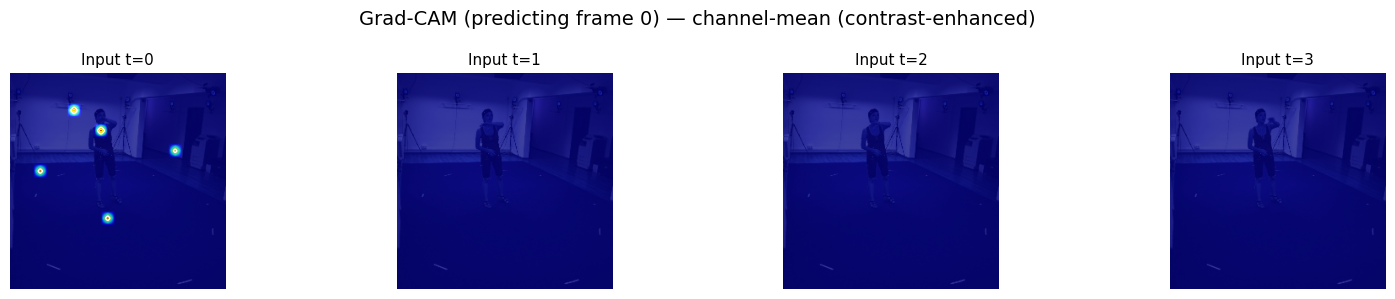

t=0: min=0.0000, max=0.0000, p95=0.0000
t=1: min=0.0000, max=0.0000, p95=0.0000
t=2: min=0.0000, max=0.0000, p95=0.0000
t=3: min=0.0000, max=0.0000, p95=0.0000


In [3]:
# --- Grad-CAM for PredFormer (4 in / 4 out), spatial attention overlay (1xT) ---
import os, sys, json, math, warnings
warnings.filterwarnings('ignore')
os.environ["CUDA_VISIBLE_DEVICES"] = "1"

import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

# ========== 1) Data & Model ==========
sys.path.append('/nas_data/LSH/OpenSTL-MOR')
from openstl.methods.PredFormer import PredFormer_method
from openstl.datasets.dataloader_human import load_data

# 与 ckpt一致
dataloader_train, _, _ = load_data(
    batch_size=1, val_batch_size=1, data_root='/nas_data/LSH/data/',
    num_workers=2, pre_seq_length=4, aft_seq_length=4,
    use_prefetcher=True, distributed=False
)
batch_x, batch_y = next(iter(dataloader_train))      # (1, 4, C, H, W)
B, T, C, H, W = batch_x.shape
print("Input:", batch_x.shape, "Target:", batch_y.shape)

with open("/nas_data/LSH/OpenSTL-MOR/work_dirs/human/predformer/facTSattion_onecycle_dim256_head8_ndepth6_patch8_tauloss/model_param.json", "r", encoding="utf-8") as f:
    config = json.load(f)
ckpt = torch.load(
    "/nas_data/LSH/OpenSTL-MOR/work_dirs/human/predformer/facTSattion_onecycle_dim256_head8_ndepth6_patch8_tauloss/checkpoints/best.ckpt",
    map_location='cpu'
)
method = PredFormer_method(steps_per_epoch=len(dataloader_train),
                           test_mean=None, test_std=None, save_dir='.', **config)
method.load_state_dict(ckpt['state_dict'])
model = method.model.eval().cuda()

# ========== 2) Hooks ==========
features, gradients = {}, {}
def fwd_hook(_m, _inp, out): features['value'] = out  # (BT,N,D) / (B,T,N,D) / ...
def bwd_hook(_m, _gin, gout): gradients['value'] = gout[0]

space_mod = model.space_transformer
h1 = space_mod.register_forward_hook(fwd_hook)
h2 = space_mod.register_full_backward_hook(bwd_hook)
print("Hook on:", space_mod.__class__.__name__)

# 如未触发，自动探针到叶子层
x = batch_x.cuda().requires_grad_(True)
_ = model(x)
if 'value' not in features:
    h1.remove(); h2.remove()
    last = {'name': None}
    probes = []
    def probe(name):
        def _p(_m, _i, o):
            if torch.is_tensor(o): last['name'] = name
        return _p
    for name, m in model.space_transformer.named_modules():
        probes.append(m.register_forward_hook(probe(name)))
    _ = model(x)
    for p in probes: p.remove()
    assert last['name'] is not None, "找不到 space_transformer 的有效输出层"
    target_module = dict(model.space_transformer.named_modules())[last['name']]
    target_module.register_forward_hook(fwd_hook)
    target_module.register_full_backward_hook(bwd_hook)
    print("🔎 Re-hook on:", last['name'])

# ========== 3) CAM 辅助函数 ==========
def infer_patch_grid(N, H, W, model):
    for attr_h, attr_w in [('num_patches_h','num_patches_w'),
                           ('patches_h','patches_w'),
                           ('grid_h','grid_w')]:
        if hasattr(model, attr_h) and hasattr(model, attr_w):
            ph = int(getattr(model, attr_h)); pw = int(getattr(model, attr_w))
            if ph * pw == N: return ph, pw
    if hasattr(model, 'patch_size'):
        ps = model.patch_size if isinstance(model.patch_size, int) else int(model.patch_size[0])
        ph, pw = H // ps, W // ps
        if ph * pw == N: return ph, pw
    s = int(math.sqrt(N))
    if s * s == N: return s, s
    for ph in range(1, N+1):
        if N % ph == 0: return ph, N // ph
    raise ValueError(f"无法推断 patch 网格: N={N}")

def cam_from_act_grad(act, grad, H, W, B, T):
    """
    支持 act/grad 形状：
      (B,T,N,D) / (B,N,T,D) / (BT,N,D) / (T,N,D)
    返回 (B,T,H,W)
    """
    if act.dim() == 4:  # (B,T,N,D) or (B,N,T,D)
        if act.shape[1] == T:
            pass
        elif act.shape[2] == T:
            act  = act.permute(0, 2, 1, 3).contiguous()
            grad = grad.permute(0, 2, 1, 3).contiguous()
        else:
            raise RuntimeError(f"4D act 无 T 维: {act.shape}, T={T}")
    elif act.dim() == 3:  # (BT,N,D) or (T,N,D)
        if act.shape[0] == B*T:
            act  = act.view(B, T, act.shape[1], act.shape[2])
            grad = grad.view(B, T, grad.shape[1], grad.shape[2])
        elif act.shape[0] == T:
            act  = act.unsqueeze(0)  # -> (1,T,N,D)
            grad = grad.unsqueeze(0)
        else:
            raise RuntimeError(f"3D act 首维既非 BT 亦非 T: {act.shape}, B={B}, T={T}")
    else:
        raise RuntimeError(f"不支持的 act 维度: {act.dim()}, shape={act.shape}")

    # 通道加权 (D 聚合)
    w = grad.mean(dim=-1, keepdim=True)       # (B,T,N,1)
    cam = torch.relu((w * act).sum(dim=-1))   # (B,T,N)

    # 归一化
    cam = cam - cam.amin(dim=(1,2), keepdim=True)
    cam = cam / (cam.amax(dim=(1,2), keepdim=True) + 1e-6)

    # N -> (ph,pw)，然后上采样到 (H,W)
    B_, T_, N_ = cam.shape
    ph, pw = infer_patch_grid(N_, H, W, model)
    cam2d   = cam.view(B_, T_, ph, pw)                 # (B,T,ph,pw)
    cam_flat= cam2d.view(B_*T_, 1, ph, pw)             # (B*T,1,ph,pw)
    cam_up  = F.interpolate(cam_flat, size=(H, W), mode='bilinear', align_corners=False)
    cam_hw  = cam_up.view(B_, T_, H, W)                # (B,T,H,W)
    return cam_hw

def make_vis_base(x_tchw):
    """(T,C,H,W)->(T,H,W,3)"""
    T_, C_, H_, W_ = x_tchw.shape
    vis = np.zeros((T_, H_, W_, 3), dtype=np.float32)
    if C_ >= 3:
        arr = x_tchw[:, :3].astype(np.float32)
        for ch in range(3):
            v = arr[:, ch]; vmin, vmax = v.min(), v.max()
            vis[:, :, :, ch] = (v - vmin) / (vmax - vmin + 1e-6) if vmax > vmin else 0
    else:
        v = x_tchw[:, 0].astype(np.float32)
        vmin, vmax = v.min(), v.max()
        v = (v - vmin) / (vmax - vmin + 1e-6) if vmax > vmin else 0
        vis[:] = v[..., None]
    return vis

def cam_normalize_per_frame(cam2d, lo_pct=1, hi_pct=99, gamma=0.7):
    lo, hi = np.percentile(cam2d, lo_pct), np.percentile(cam2d, hi_pct)
    if hi > lo:
        x = (cam2d - lo) / (hi - lo + 1e-6)
    else:
        x = cam2d - cam2d.min(); x = x / (x.max() - x.min() + 1e-6)
    x = np.clip(x, 0, 1)
    if gamma is not None: x = np.power(x, gamma)  # gamma<1提亮高值
    return x

def overlay(img, mask, alpha=0.75):
    cmap = plt.get_cmap('jet')
    heat = cmap(mask)[:, :, :3]
    out  = alpha * heat + (1 - alpha) * img
    return np.clip(out, 0, 1)

# ========== 4) 选择目标并反传 ==========
PRED_FRAME = 0  # 0/1/2/3

# 前向
x = batch_x.cuda().requires_grad_(True)
out = model(x)                                   # (1,4,C,H,W)
print("Output:", out.shape)

# ---- 目标(三选一)：默认通道均值 ----
# A) 通道均值（整体关注）
target = out[:, PRED_FRAME].mean()

# B) ROI 目标（取消注释使用）
# y0,y1,x0,x1 = 112,144,112,144
# target = out[:, PRED_FRAME, :, y0:y1, x0:x1].mean()

# C) 单像素目标（取消注释使用）
# yy, xx = H//2, W//2
# target = out[:, PRED_FRAME, :, yy, xx].mean()

model.zero_grad(set_to_none=True)
target.backward()

assert 'value' in features and 'value' in gradients, "Hook 未触发，请检查绑定层"
act, grad = features['value'], gradients['value']
cam_bt_hw  = cam_from_act_grad(act, grad, H, W, B=B, T=T)    # (B,T,H,W)
cam_t_hw   = cam_bt_hw[0].detach().cpu().numpy()             # (4,H,W)

# ========== 5) 叠加可视化 (1xT) ==========
base = make_vis_base(batch_x[0].detach().cpu().numpy())      # (4,H,W,3)

fig, axes = plt.subplots(1, T, figsize=(4*T, 3))
for t in range(T):
    cam_vis = cam_normalize_per_frame(cam_t_hw[t], lo_pct=1, hi_pct=99, gamma=0.7)
    over    = overlay(base[t], cam_vis, alpha=0.75)
    ax = axes[t]
    ax.imshow(over)
    # 等值线辅助（可注释掉）
    ax.contour(cam_vis, levels=[0.6, 0.8], colors=['white','yellow'], linewidths=1.0)
    ax.set_title(f'Input t={t}', fontsize=11)
    ax.axis('off')

plt.suptitle(f'Grad-CAM (predicting frame {PRED_FRAME}) — channel-mean (contrast-enhanced)', fontsize=14)
plt.tight_layout()
plt.show()

# （可选）打印每帧 CAM 数值范围
for t in range(T):
    m = cam_t_hw[t]
    print(f"t={t}: min={m.min():.4f}, max={m.max():.4f}, p95={np.percentile(m,95):.4f}")
